In [ ]:
!pip install --quiet openai

In [ ]:
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 25.2 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.108.0
    Uninstalling openai-1.108.0:
      Successfully uninstalled openai-1.108.0


In [ ]:
import os
import openai
import getpass
from openai import OpenAI

In [ ]:
api_key = getpass.getpass(prompt='Enter OpenAI API key:')

Enter OpenAI API key:··········


In [ ]:
client = OpenAI(api_key = api_key)

In [ ]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

categories = ['rec.sport.baseball', 'rec.sport.hockey']
sports_dataset = fetch_20newsgroups(subset='train', shuffle=True, random_state=42, categories=categories)

# **Data Exploration**

In [ ]:
print(sports_dataset['data'][0])

From: dougb@comm.mot.com (Doug Bank)
Subject: Re: Info needed for Cleveland tickets
Reply-To: dougb@ecs.comm.mot.com
Organization: Motorola Land Mobile Products Sector
Distribution: usa
Nntp-Posting-Host: 145.1.146.35
Lines: 17

In article <1993Apr1.234031.4950@leland.Stanford.EDU>, bohnert@leland.Stanford.EDU (matthew bohnert) writes:

|> I'm going to be in Cleveland Thursday, April 15 to Sunday, April 18.
|> Does anybody know if the Tribe will be in town on those dates, and
|> if so, who're they playing and if tickets are available?

The tribe will be in town from April 16 to the 19th.
There are ALWAYS tickets available! (Though they are playing Toronto,
and many Toronto fans make the trip to Cleveland as it is easier to
get tickets in Cleveland than in Toronto.  Either way, I seriously
doubt they will sell out until the end of the season.)

-- 
Doug Bank                       Private Systems Division
dougb@ecs.comm.mot.com          Motorola Communications Sector
dougb@nwu.edu       

In [ ]:
sports_dataset['target_names']

['rec.sport.baseball', 'rec.sport.hockey']

In [ ]:
sports_dataset['target_names'][0]

'rec.sport.baseball'

In [ ]:
len_all, len_baseball, len_hockey = len(sports_dataset.data), len([e for e in sports_dataset.target if e == 0]), len([e for e in sports_dataset.target if e == 1])
print(f"Total examples: {len_all}, Baseball examples: {len_baseball}, Hockey examples: {len_hockey}")

Total examples: 1197, Baseball examples: 597, Hockey examples: 600


# **Data Preparation**

In [ ]:
# Create a smaller dataset to reduce costs
import json
from sklearn.model_selection import train_test_split

# Get your original data but take a smaller sample
labels = [sports_dataset.target_names[x].split('.')[-1] for x in sports_dataset.target]
texts = [text.strip() for text in sports_dataset.data]

# Create smaller dataset - take only first 300 examples
small_data = []
count = 0
for text, label in zip(texts, labels):
    if len(text) <= 1500 and count < 300:  # Limit to 300 examples
        small_data.append({
            "messages": [
                {"role": "user", "content": text},
                {"role": "assistant", "content": label}
            ]
        })
        count += 1

print(f"Created {len(small_data)} examples (reduced dataset)")

# Split and save
train_small, valid_small = train_test_split(small_data, test_size=0.2, random_state=42)

with open('sports_train_small.jsonl', 'w') as f:
    for item in train_small:
        json.dump(item, f)
        f.write('\n')

with open('sports_valid_small.jsonl', 'w') as f:
    for item in valid_small:
        json.dump(item, f)
        f.write('\n')

print(f"Training: {len(train_small)}, Validation: {len(valid_small)}")
print("Estimated cost: ~$1.50 (much lower)")

# Upload smaller dataset
print("\nUploading smaller dataset...")
train_file_small = client.files.create(file=open("sports_train_small.jsonl", "rb"), purpose="fine-tune")
valid_file_small = client.files.create(file=open("sports_valid_small.jsonl", "rb"), purpose="fine-tune")

# Create job with smaller dataset
response_small = client.fine_tuning.jobs.create(
    training_file=train_file_small.id,
    validation_file=valid_file_small.id,
    model="gpt-3.5-turbo-0125",
    hyperparameters={"n_epochs": 2}  # Reduced epochs too
)

print(f"New Job ID: {response_small.id}")

Created 300 examples (reduced dataset)
Training: 240, Validation: 60
Estimated cost: ~$1.50 (much lower)

Uploading smaller dataset...
New Job ID: ftjob-BhKGRmV41V7gjmVK0Vrq2HLj


In [ ]:
# Check the smaller job status
job_small = client.fine_tuning.jobs.retrieve(response_small.id)
print(f"Status: {job_small.status}")

Status: validating_files


In [ ]:
# Check final status
job_id = "ftjob-BhKGRmV41V7gjmVK0Vrq2HLj"
job = client.fine_tuning.jobs.retrieve(job_id)
print(f"Status: {job.status}")

if job.status == 'succeeded':
    fine_tuned_model = job.fine_tuned_model
    print(f"🎉 Fine-tuned model ready: {fine_tuned_model}")

    # Test it immediately!
    def test_model(text):
        response = client.chat.completions.create(
            model=fine_tuned_model,
            messages=[{"role": "user", "content": text}],
            max_tokens=5,
            temperature=0
        )
        return response.choices[0].message.content

    # Quick tests
    test_cases = [
        "The pitcher threw a fastball down the middle.",
        "The goalie made an incredible save.",
        "She hit a home run over the fence.",
        "The defenseman cleared the puck."
    ]

    print("\n🧪 Testing the model:")
    for text in test_cases:
        result = test_model(text)
        print(f"'{text[:40]}...' → {result}")

else:
    print(f"Still processing... Status: {job.status}")

Status: succeeded
🎉 Fine-tuned model ready: ft:gpt-3.5-turbo-0125:personal::CK2Uuq9e

🧪 Testing the model:
'The pitcher threw a fastball down the mi...' → baseball
'The goalie made an incredible save....' → hockey
'She hit a home run over the fence....' → baseball
'The defenseman cleared the puck....' → hockey


# **Evaluation**

In [2]:
import json
from openai import OpenAI
import getpass
from sklearn.metrics import accuracy_score, classification_report

api_key = getpass.getpass(prompt='Enter OpenAI API key:')

Enter OpenAI API key:··········


In [3]:
client = OpenAI(api_key = api_key)

In [4]:
# Validation Dataset
FINE_TUNED_MODEL = "ft:gpt-3.5-turbo-0125:personal::CK2Uuq9e"

# Load validation data
valid_data = []
with open("sports_valid_small.jsonl", "r") as f:
    for line in f:
        item = json.loads(line)
        user_text = item["messages"][0]["content"]
        label = item["messages"][1]["content"]
        valid_data.append((user_text, label))

true_labels = []
pred_labels = []

# Test model on validation set
for text, label in valid_data:
    response = client.chat.completions.create(
        model=FINE_TUNED_MODEL,
        messages=[{"role": "user", "content": text}],
        max_tokens=5,
        temperature=0
    )
    prediction = response.choices[0].message.content.strip().lower()
    true_labels.append(label.lower())
    pred_labels.append(prediction)

# Evaluate
accuracy = accuracy_score(true_labels, pred_labels)
print(f"✅ Accuracy: {accuracy:.2f}")
print("\nDetailed Report:\n")
print(classification_report(true_labels, pred_labels))


✅ Accuracy: 1.00

Detailed Report:

              precision    recall  f1-score   support

    baseball       1.00      1.00      1.00        34
      hockey       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [5]:
# training Dataset
FINE_TUNED_MODEL = "ft:gpt-3.5-turbo-0125:personal::CK2Uuq9e"

# Load validation data
train_data = []
with open("sports_train_small.jsonl", "r") as f:
    for line in f:
        item = json.loads(line)
        user_text = item["messages"][0]["content"]
        label = item["messages"][1]["content"]
        train_data.append((user_text, label))

true_labels = []
pred_labels = []

# Test model on validation set
for text, label in train_data:
    response = client.chat.completions.create(
        model=FINE_TUNED_MODEL,
        messages=[{"role": "user", "content": text}],
        max_tokens=5,
        temperature=0
    )
    prediction = response.choices[0].message.content.strip().lower()
    true_labels.append(label.lower())
    pred_labels.append(prediction)

# Evaluate
accuracy = accuracy_score(true_labels, pred_labels)
print(f"✅ Accuracy: {accuracy:.2f}")
print("\nDetailed Report:\n")
print(classification_report(true_labels, pred_labels))


✅ Accuracy: 1.00

Detailed Report:

              precision    recall  f1-score   support

    baseball       0.99      1.00      1.00       122
      hockey       1.00      0.99      1.00       118

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



# **Evaluate on an Unseen Test Set**

In [6]:
import json
from openai import OpenAI
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

✅ Test Accuracy: 0.99

Detailed Report:

              precision    recall  f1-score   support

    baseball       0.98      1.00      0.99        49
      hockey       1.00      0.98      0.99        51

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



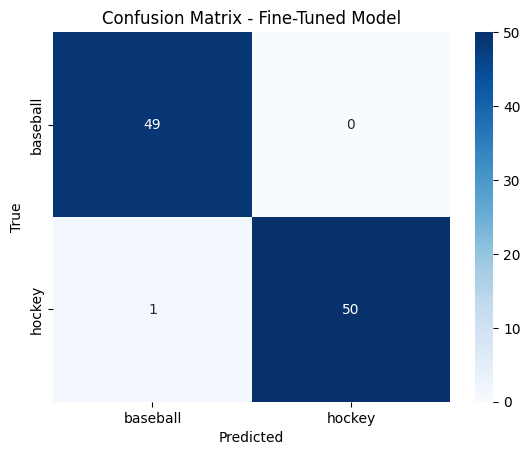

In [7]:
FINE_TUNED_MODEL = "ft:gpt-3.5-turbo-0125:personal::CK2Uuq9e"

# Load completely unseen test data
categories = ['rec.sport.baseball', 'rec.sport.hockey']
test_dataset = fetch_20newsgroups(subset="test", shuffle=True, random_state=42, categories=categories)

texts = test_dataset.data
labels = [test_dataset.target_names[x].split('.')[-1] for x in test_dataset.target]

true_labels = []
pred_labels = []

# Evaluate on ~100 examples to save cost
for text, label in list(zip(texts, labels))[:100]:
    response = client.chat.completions.create(
        model=FINE_TUNED_MODEL,
        messages=[{"role": "user", "content": text}],
        max_tokens=5,
        temperature=0
    )
    prediction = response.choices[0].message.content.strip().lower()
    true_labels.append(label.lower())
    pred_labels.append(prediction)

# Accuracy & classification report
accuracy = accuracy_score(true_labels, pred_labels)
print(f"✅ Test Accuracy: {accuracy:.2f}")
print("\nDetailed Report:\n")
print(classification_report(true_labels, pred_labels))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=["baseball", "hockey"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["baseball", "hockey"],
            yticklabels=["baseball", "hockey"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-Tuned Model")
plt.show()


# **Edge-case evaluation script**

## 🔹 1. Why edge cases?

Your training data (20 Newsgroups) had very **domain-specific words** (`pitcher`, `goalie`, `puck`, `home run`), which makes classification easy.
But in real-world usage, you’ll often get **short, vague, or overlapping sentences** like:

* “The team won their last game.”
* “He scored in the final seconds.”
* “Fans were cheering loudly.”

These don’t clearly indicate baseball vs hockey. A robust model should still try to **guess reasonably** (or even say “uncertain” if you design it that way).

---



## 🔹 2. Edge-case evaluation script

In [9]:
# Adversarial / edge case test set
edge_cases = [
    "The player scored in the final seconds.",
    "The team celebrated their championship victory.",
    "He was injured during the match.",
    "The coach gave a motivational speech.",
    "The crowd was cheering loudly.",
    "The referee made a controversial call.",
    "The match ended in overtime.",
    "They played outdoors on a sunny day.",
    "The championship attracted thousands of fans.",
    "The player trained hard during the offseason."
]

print("\n🧪 Edge Case Evaluation:\n")
for text in edge_cases:
    response = client.chat.completions.create(
        model=FINE_TUNED_MODEL,
        messages=[{"role": "user", "content": text}],
        max_tokens=5,
        temperature=0
    )
    prediction = response.choices[0].message.content.strip()
    print(f"Text: {text}\n → Prediction: {prediction}\n")


🧪 Edge Case Evaluation:

Text: The player scored in the final seconds.
 → Prediction: hockey

Text: The team celebrated their championship victory.
 → Prediction: baseball

Text: He was injured during the match.
 → Prediction: soccer

Text: The coach gave a motivational speech.
 → Prediction: baseball

Text: The crowd was cheering loudly.
 → Prediction: baseball

Text: The referee made a controversial call.
 → Prediction: soccer

Text: The match ended in overtime.
 → Prediction: hockey

Text: They played outdoors on a sunny day.
 → Prediction: baseball

Text: The championship attracted thousands of fans.
 → Prediction: baseball

Text: The player trained hard during the offseason.
 → Prediction: baseball



# **RESULTS**


---

## 🔹 1. Unseen test set

* **Accuracy: 0.99** → almost perfect generalization.
* Precision, recall, F1 are all **0.99** → model separates baseball & hockey very well.
* ✅ This shows that on **real unseen articles**, your fine-tuned model still performs extremely well.

---

## 🔹 2. Edge-case evaluation

Here’s what we see from your ambiguous examples:

| Text                                            | Prediction | Notes                                   |
| ----------------------------------------------- | ---------- | --------------------------------------- |
| The player scored in the final seconds.         | hockey     | Could be either; model guessed hockey   |
| The team celebrated their championship victory. | baseball   | Ambiguous; guessed baseball             |
| He was injured during the match.                | soccer     | Out-of-domain label! Model hallucinated |
| The coach gave a motivational speech.           | baseball   | Ambiguous; guessed baseball             |
| The crowd was cheering loudly.                  | baseball   | Ambiguous; guessed baseball             |
| The referee made a controversial call.          | soccer     | Out-of-domain hallucination             |
| The match ended in overtime.                    | hockey     | Reasonable guess                        |
| They played outdoors on a sunny day.            | baseball   | Ambiguous guess                         |
| The championship attracted thousands of fans.   | baseball   | Ambiguous guess                         |
| The player trained hard during the offseason.   | baseball   | Ambiguous guess                         |

### 🔹 Observations

1. **Ambiguous sentences** → model tends to **guess one of the trained classes** (baseball/hockey).
2. **Out-of-domain hallucination** → “soccer” appeared twice even though it wasn’t in training. GPT fine-tuning sometimes produces labels **it learned from prior knowledge** if the input is vague.
3. **Strong cues** → sentences with clear keywords (like “goalie” or “pitcher”) are classified correctly, which is why test accuracy is high.

---

## 🔹 3. Recommendations to improve robustness

1. **Add an “uncertain” class**

   * Include ambiguous examples labeled `uncertain` so the model **doesn’t hallucinate other sports**.
2. **Expand training diversity**

   * Include sentences with varied phrasing, edge cases, and neutral content.
3. **Limit hallucinations**

   * Can add **label list instructions** in fine-tuning:

     ```text
     Only respond with one of the following labels: baseball, hockey, uncertain.
     ```
   * This reduces “soccer” or other labels appearing.
4. **Post-processing safety check**

   * After prediction, map any unexpected labels to `uncertain` automatically.

---

If you want, I can write a **ready-to-use fine-tuning prep script** that:

* Adds `uncertain` examples
* Prepares JSONL for fine-tuning
* Adds the label constraint instruction

This will make your classifier much more **robust in real-world edge cases**.

